**LOAN DEFAULT PREDICTION SYSTEM**

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [ ]:
import pandas as pd
#Load the Loan Default Prediction Data
df=pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

In [ ]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df.shape

(255347, 18)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [ ]:
import pandas as pd
df=pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)
print(df.isnull().sum())

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


Default rate: 11.6%


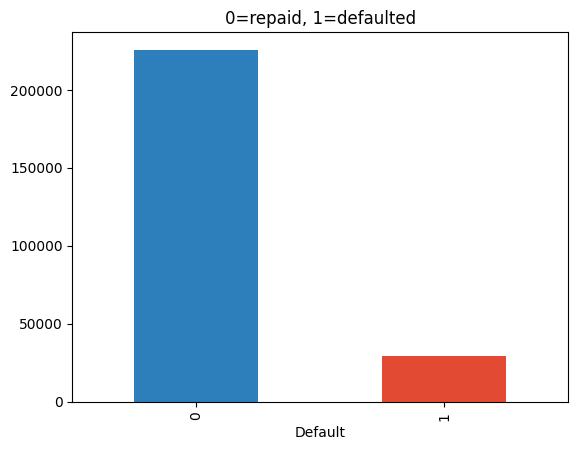

In [ ]:
#NOTE: Only 12% default. The data is imbalanced keep an eye on it not just as accuracy.
#Target balance-What % actually default?
import matplotlib.pyplot as plt
rate=df['Default'].mean()
print(f'Default rate: {rate:.1%}')
df['Default'].value_counts().plot(kind='bar', color=['#2c7fba','#e34a33'])
plt.title('0=repaid, 1=defaulted')
plt.show()

In [ ]:
print(df['Default'].value_counts(dropna=False))

Default
0    225694
1     29653
Name: count, dtype: int64


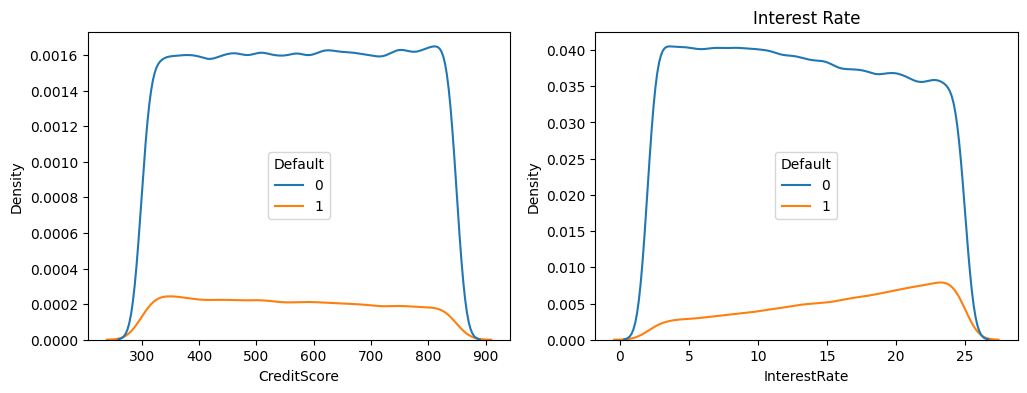

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#For there credit score and Interest rate
df['CreditScore'] = pd.to_numeric(df['CreditScore'], errors='coerce')
df['InterestRate'] = pd.to_numeric(df['InterestRate'], errors='coerce')
fig, ax =plt.subplots(1,2, figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', ax=ax[0])
sns.kdeplot(data=df, x='InterestRate', hue='Default', ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

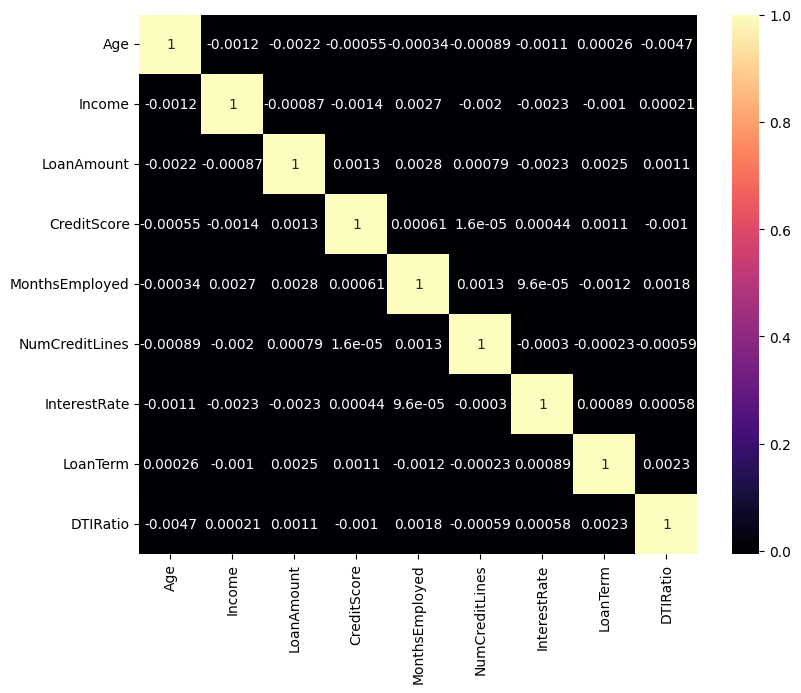

In [ ]:
#The Correlation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

num=['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

# Ensure all columns in 'num' are numeric, coercing errors
for col in num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(9,7))
sns.heatmap(df[num].select_dtypes(include=np.number).corr(), annot=True, cmap='magma')
plt.show()

**ONE HOT ENCODING**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Reload the dataframe to ensure a clean state after a potential crash
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID' as it's a unique identifier and not useful for encoding or modeling
df = df.drop(columns=['LoanID'])

# Perform one-hot encoding on the remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('X_train shape:', x_train.shape, 'X_test shape:', x_test.shape)

X_train shape: (204277, 24) X_test shape: (51070, 24)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the DataFrame df
df = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

df_enc = pd.get_dummies(df, drop_first=True)
x = df_enc.drop(columns=['Default'])
y = df_enc['Default']
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
print('train:', x_train.shape, 'test:', x_test.shape)

**Model Building**

**Logistic Regression**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Ensure df is prepared correctly before splitting
# Reload the dataframe to ensure a clean state (as done in previous preprocessing cells)
df_current = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID' as it's a unique identifier and not useful for encoding or modeling
df_current = df_current.drop(columns=['LoanID'])

# Perform one-hot encoding on the remaining categorical columns
df_encoded = pd.get_dummies(df_current, drop_first=True)

# Define features (x) and target (y)
x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# train a logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small data
log_reg_model.fit(x_train, y_train)

#Make predictions on the test set
y_pred = log_reg_model.predict(x_test)

#Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred)
f1_log_reg = f1_score(y_test, y_pred)

print(f'Logistic Regression Accuracy: {accuracy_log_reg:.4f}')
print(f'Logistic Regression F1 Score: {f1_log_reg:.4f}')

Logistic Regression Accuracy: 0.8849
Logistic Regression F1 Score: 0.0249


**Logistic Regression Feature Importance**

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': log_reg_model.coef_[0]
    })
feature_importance['absolute importance'] = abs(feature_importance['Importance'])
feature_importance = feature_importance.sort_values(by='absolute importance', ascending=False)
feature_importance.head(10)

,Feature,Importance,absolute importance
6,InterestRate,0.054588,0.054588
0,Age,-0.035095,0.035095
4,MonthsEmployed,-0.009948,0.009948
5,NumCreditLines,0.002981,0.002981
7,LoanTerm,-0.002361,0.002361
23,HasCoSigner_Yes,-0.001949,0.001949
18,HasDependents_Yes,-0.001668,0.001668
14,EmploymentType_Unemployed,0.001475,0.001475
15,MaritalStatus_Married,-0.001126,0.001126
17,HasMortgage_Yes,-0.001014,0.001014


**Random Forest**

In [ ]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

rf_model = RandomForestClassifier(n_estimators=200,
                                  max_depth=10,
                                  random_state=42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred)
f1_rf = f1_score(y_test, y_pred)

#Evaluate the model
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
print(f'Random Forest F1 Score: {f1_rf:.4f}')

Random Forest Accuracy: 0.8849
Random Forest F1 Score: 0.0104


In [ ]:
#Feature Importance
feature_importance_rf = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
    }).sort_values(
        by='Importance',
        ascending=False
        )

feature_importance_rf

,Feature,Importance
0,Age,0.233990
1,Income,0.188544
6,InterestRate,0.164733
2,LoanAmount,0.117771
4,MonthsEmployed,0.098850
3,CreditScore,0.048633
8,DTIRatio,0.034293
5,NumCreditLines,0.013695
23,HasCoSigner_Yes,0.012642
7,LoanTerm,0.012154


**XGBOOST**

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=10,
    random_state=42
)
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred)

#Evaluate the model
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')
print(f'XGBoost F1 Score: {f1_xgb:.4f}')

XGBoost Accuracy: 0.8870
XGBoost F1 Score: 0.1344


**XGBOOST Feature Importance**

In [ ]:
feature_importance_xgb = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_
    }).sort_values(
        by='Importance',
        ascending=False
        )

feature_importance_xgb

,Feature,Importance
0,Age,0.086675
6,InterestRate,0.057674
1,Income,0.055446
2,LoanAmount,0.048337
23,HasCoSigner_Yes,0.047958
14,EmploymentType_Unemployed,0.047513
4,MonthsEmployed,0.047217
18,HasDependents_Yes,0.045739
15,MaritalStatus_Married,0.042906
21,LoanPurpose_Home,0.040094


**Compare All These Three Models**

In [ ]:
#Comparing all the three models
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
      ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
      ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
      ]
    })
comparison.sort_values(
    by='F1 Score',
    ascending=False)

,Model,Accuracy,F1 Score
2,XGBoost,0.886959,0.134353
0,Logistic Regression,0.884903,0.024884
1,Random Forest,0.884923,0.010439


**Visualize the Models**

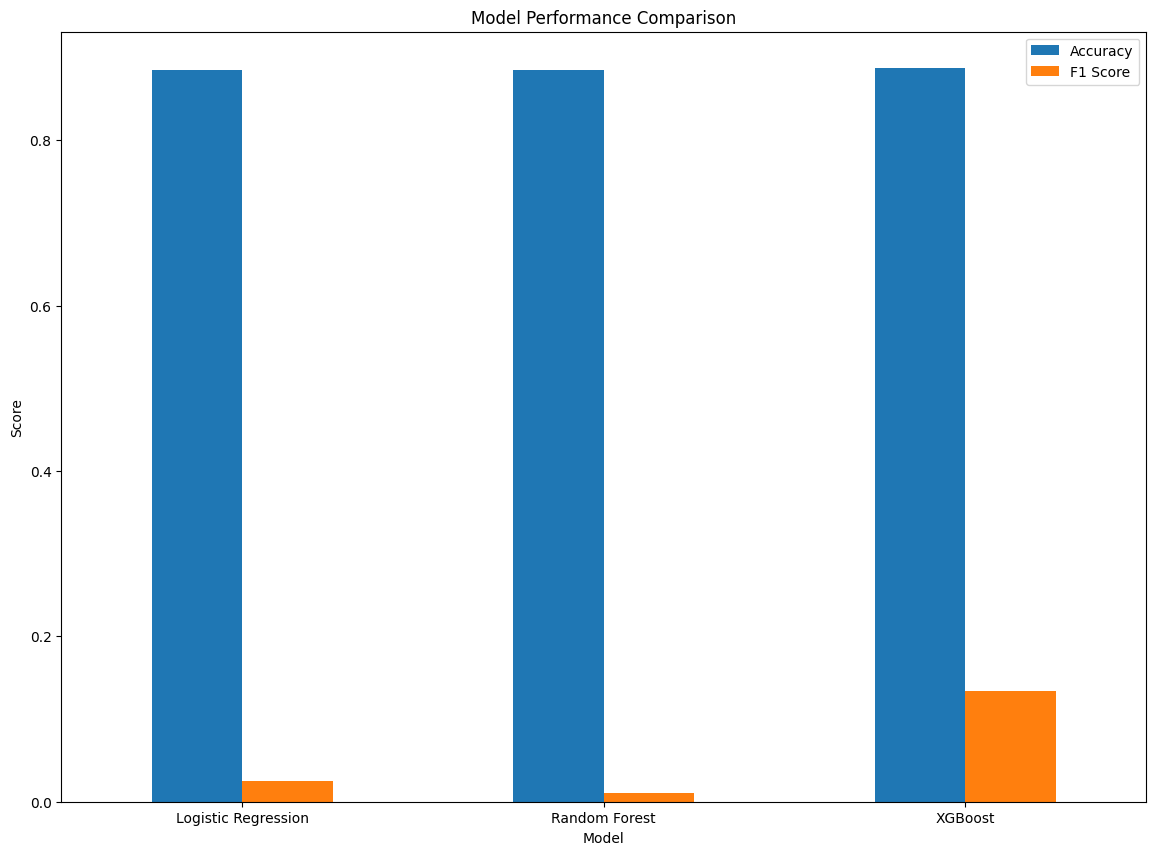

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- Start: Ensure all necessary variables are defined ---

# Load the dataframe
df_current = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID'
df_current = df_current.drop(columns=['LoanID'])

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_current, drop_first=True)

# Define features (x) and target (y)
x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 1. Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(x_train, y_train)
y_pred_log_reg = log_reg_model.predict(x_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# 3. XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=10, random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# --- End: Ensure all necessary variables are defined ---

# Re-create the comparison DataFrame to ensure it's defined
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
      ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
      ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
      ]
    })

# comparison set
comparison.set_index('Model')[['Accuracy', 'F1 Score']].plot(
    kind='bar',
    figsize=(14,10)
    )

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

**Select the best Model Automatically**

In [ ]:
best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
    ).iloc[0]['Model']

print(f"best Model: {best_model_name}")

best Model: XGBoost


**Save Model**

In [5]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# --- Start: Ensure all necessary variables are defined ---

# Load the dataframe
df_current = pd.read_csv('/content/Loan_default.csv', on_bad_lines='skip', low_memory=False)

# Drop 'LoanID'
df_current = df_current.drop(columns=['LoanID'])

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_current, drop_first=True)

# Define features (x) and target (y)
x = df_encoded.drop(columns=['Default'])
y = df_encoded['Default']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 1. Logistic Regression Model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(x_train, y_train)
y_pred_log_reg = log_reg_model.predict(x_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
f1_log_reg = f1_score(y_test, y_pred_log_reg)

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# 3. XGBoost Classifier
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=10, random_state=42)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# --- End: Ensure all necessary variables are defined ---

# Re-create the comparison DataFrame to ensure it's defined and the variables are in scope
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
      ],
    'Accuracy': [
        accuracy_log_reg,
        accuracy_rf,
        accuracy_xgb
      ],
    'F1 Score': [
        f1_log_reg,
        f1_rf,
        f1_xgb
      ]
    })

best_model_name = comparison.sort_values(
    by='F1 Score',
    ascending=False
    ).iloc[0]['Model']

if best_model_name == 'Logistic Regression':
  best_model = log_reg_model
elif best_model_name == 'Random Forest':
  best_model = rf_model
else:
  best_model = xgb_model

joblib.dump(best_model, 'loan_default_model.pkl')
print("Best model saved successfully!")

Best model saved successfully!


**STREAMLIT APPLICATION**

App.py

In [6]:
app_py_content = """
import streamlit as st
import pandas as pd
import joblib

# PAGE CONFIGURATION

st.set_page_config(
    page_title="Loan Default Prediction",
    page_icon="💳",
    layout="wide"
)

# LOAD MODEL

model = joblib.load("loan_default_model.pkl")

# CUSTOM CSS
st.markdown('''
<style>

.main {
    background-color: #F8FAFC;
}

.title {
    text-align:center;
    color:#1E3A8A;
    font-size:45px;
    font-weight:700;
}
.subtitle {
    text-align:center;
    color:#64748B;
    font-size:18px;
}

.metric-card {
    background-color:white;
    padding:15px;
    border-radius:12px;
    box-shadow:0px 2px 10px rgba(0,0,0,0.08);
}
.stButton > button {
    width:100%;
    height:55px;
    border-radius:12px;
    font-size:18px;
    font-weight:bold;
}

</style>
''', unsafe_allow_html=True)

# SIDEBAR

with st.sidebar:

    st.image(
        "https://cdn-icons-png.flaticon.com/512/3135/3135715.png",
        width=150
    )

    st.title("📊 Project Overview")

    st.markdown('''
    ### Models Used

    - Logistic Regression
    - Random Forest
    - XGBoost

    ### Objective

    Predict whether a borrower is likely to default on a loan.

    ### Features

    - Real-time prediction
    - Risk probability
    - ML-powered decision support
    ''')

    st.divider()

    st.info(
        "Built with Streamlit, Scikit-Learn and XGBoost."
    )

# HEADER

st.markdown(
    "<p class='title'>💳 Loan Default Prediction System</p>",
    unsafe_allow_html=True
)

st.markdown(
    "<p class='subtitle'>Machine Learning Powered Credit Risk Assessment Dashboard</p>",
    unsafe_allow_html=True
)

st.divider()

# INPUT SECTION

col1, col2, col3 = st.columns(3)

with col1:

    Age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    Income = st.number_input(
        "Income",
        min_value=1000,
        value=50000
    )

    LoanAmount = st.number_input(
        "Loan Amount",
        min_value=1000,
        value=10000
    )

with col2:

    CreditScore = st.number_input(
        "Credit Score",
        min_value=300,
        max_value=850,
        value=650
    )

    InterestRate = st.number_input(
        "Interest Rate (%)",
        min_value=1.0,
        max_value=40.0,
        value=10.0
    )

    LoanTerm = st.number_input(
        "Loan Term (Months)",
        min_value=6,
        max_value=360,
        value=36
    )

with col3:

    MonthsEmployed = st.number_input(
        "Months Employed",
        min_value=0,
        value=24
    )

    NumCreditLines = st.number_input(
        "Number of Credit Lines",
        min_value=0,
        value=5
    )

    DTIRatio = st.number_input(
        "Debt-to-Income Ratio",
        min_value=0.0,
        max_value=1.0,
        value=0.30
    )

# PREDICTION

if st.button("🔍 Predict Loan Risk"):

    # Create a dictionary for the input features
    input_dict = {
        'Age': [Age],
        'Income': [Income],
        'LoanAmount': [LoanAmount],
        'CreditScore': [CreditScore],
        'MonthsEmployed': [MonthsEmployed],
        'NumCreditLines': [NumCreditLines],
        'InterestRate': [InterestRate],
        'LoanTerm': [LoanTerm],
        'DTIRatio': [DTIRatio]
    }

    # Create a DataFrame from the input dictionary
    input_data_df = pd.DataFrame(input_dict)

    # Get the column names from the training data X
    # This list is obtained from the kernel state's 'X' variable.
    expected_columns = [
        'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
        'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio',
        'Education_High School', "Education_Master's", 'Education_PhD',
        'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Un',
        'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single',
        'HasMortgage_Yes', 'HasDependents_Yes', 'LoanPurpose_Business',
        'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other',
        'HasCoSigner_Yes'
    ]

    # Create an empty DataFrame with all expected columns
    final_input_df = pd.DataFrame(columns=expected_columns)

    # Populate the known numeric features
    for col in input_data_df.columns:
        if col in final_input_df.columns:
            final_input_df[col] = input_data_df[col]

    # Fill all other columns (categorical one-hot encoded) with 0
    for col in final_input_df.columns:
        if col not in input_data_df.columns:
            final_input_df[col] = 0

    # Ensure the order of columns matches the training data 'X'
    final_input_df = final_input_df[expected_columns]

    prediction = model.predict(final_input_df)[0]

    probability = model.predict_proba(
        final_input_df
    )[0][1]

    st.divider()

    st.subheader("Prediction Result")

    colA, colB = st.columns(2)

    with colA:

        if prediction == 1:

            st.error(
                f'''
                ⚠️ HIGH DEFAULT RISK

                Probability of Default:
                {probability:.2%}
                '''
            )

        else:

            st.success(
                f'''
                ✅ LOW DEFAULT RISK

                Confidence:
                {(1-probability):.2%}
                '''
            )

    with colB:

        st.metric(
            "Default Probability",
            f"{probability:.2%}"
        )

        st.progress(float(probability))
    st.metric(
        "Risk Level",
        "High Risk" if prediction == 1 else "Low Risk"
    )

# FOOTER

st.divider()

st.caption(
    "Loan Default Prediction Dashboard | Machine Learning Project"
)
"""

with open("app.py", "w") as f:
    f.write(app_py_content)

print("app.py has been created successfully!")

app.py has been created successfully!


The Requirement in the App_py

In [7]:
#requirement
import pkg_resources
installed_packages = {d.project_name: d.version for d in pkg_resources.working_set}
required_packages = [
    'streamlit',
    'pandas',
    'joblib',
    'scikit-learn',
    'xgboost',
    'matplotlib',
    'seaborn'
]
# Create the requirements.txt content
requirements_content = []
for pkg in required_packages:
    if pkg in installed_packages:
        requirements_content.append(f"{pkg}=={installed_packages[pkg]}")
    else:
        print(f"Warning: Package '{pkg}' not found in installed packages. Please ensure it's installed.")

# Write to requirements.txt file
with open("requirements.txt", "w") as f:
    f.write("\n".join(requirements_content))

print("requirements.txt has been created successfully!")

/tmp/ipykernel_1522/3987120108.py:2: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


requirements.txt has been created successfully!
